<a href="https://colab.research.google.com/github/WithoutAnyTime/DataExploration/blob/main/Zaj3EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
fullData = pd.read_csv('train.csv')

In [48]:
fullData.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [49]:
fullData.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [10]:
#Mediana ceny
print(f' {fullData["SalePrice"].median()}')
#Średnia Ceny
print(f' {fullData["SalePrice"].mean()}')


 163000.0
 180921.19589041095


Wstępnie z tego widzimy, że parę domów o bardzo wysokiej cenie w dużym stopniu wpływają na średnią cenę domów w tych danych.
Zwizualizujmy cenę domów żeby zobaczyć to dokładniej.

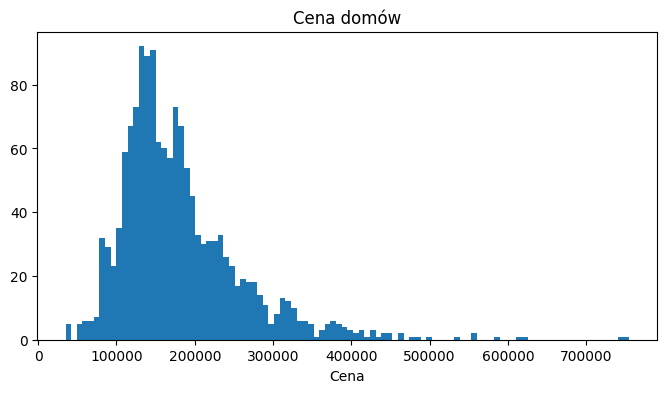

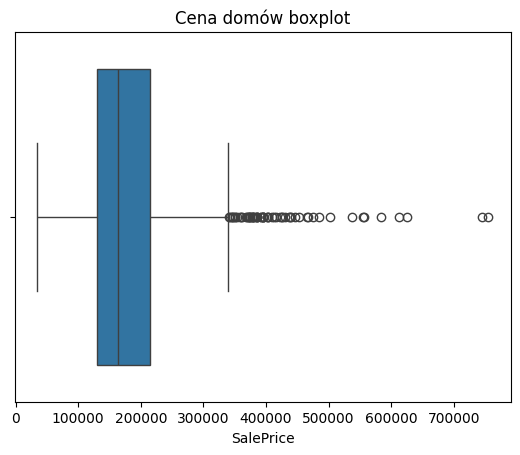

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(fullData["SalePrice"], bins=100)
plt.title('Cena domów')
plt.xlabel('Cena')
plt.show()
sns.boxplot(x=fullData["SalePrice"])
plt.title('Cena domów boxplot')
plt.show()

Jak tutaj dobrze widać na obu wykresach, ale najlepiej na boxplocie, większość domów znajduje się w przedziale 130000-220000 oprócz paru wyjątków które bardzo wpływają na średnią cenę domu.

Spróbuję teraz zrobić parę wykresów aby zaobrazować zwiększanie się ceny z paroma atrybutami znajdującymi się w naszych danych treningowych, mianowicie dwóch najważniejszych danych: Powierzchnia działki oraz powierzchnia domu.

<Axes: xlabel='LotArea', ylabel='SalePrice'>

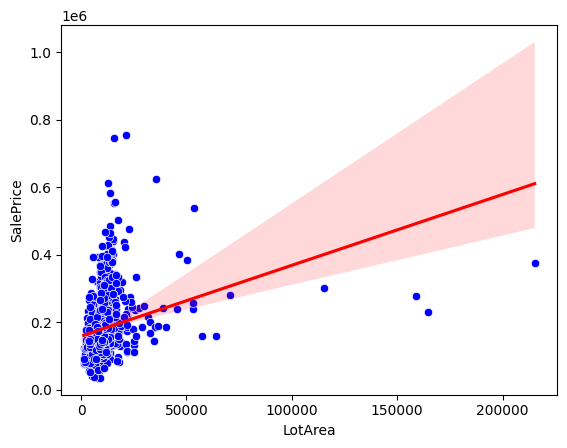

In [37]:
sns.scatterplot(data=fullData, x='LotArea', y='SalePrice', color='blue')
sns.regplot(data=fullData, x='LotArea', y='SalePrice', scatter=False, color='red')

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

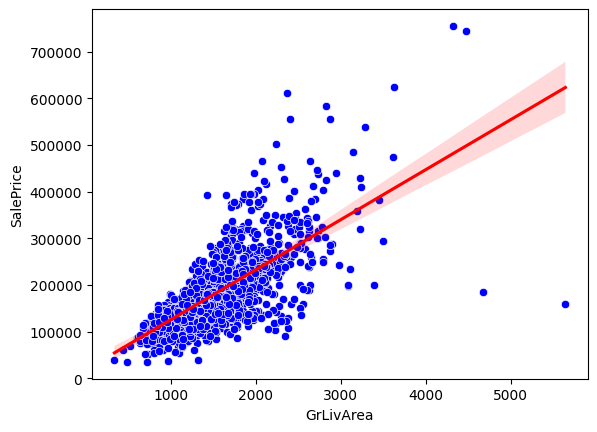

In [36]:
sns.scatterplot(data=fullData, x='GrLivArea', y='SalePrice', color='blue')
sns.regplot(data=fullData, x='GrLivArea', y='SalePrice', scatter=False, color='red')

Tutaj możemy zobaczyć że powierzchnia domu oraz powierzchnia działki mają wpływ na cenę, ale jest ona o wiele bardziej związana z powierzchnią domu niż działki.

Cena w porównaniu do powierzchni domu jest całkiem liniowo zależna, ale tak jak powiedziałem wcześniej jest parę "Dziwnych" punktów, czyli domy z dużą powierzchnią zadziwiająco tanie oraz domy z porównywalnie małą powierzchnią które są droższe niż by na to wskazywała sama powierzchnia domu.


Zróbmy teraz podobne porównanie dla paru innych, mniej ważnych atrybutów.

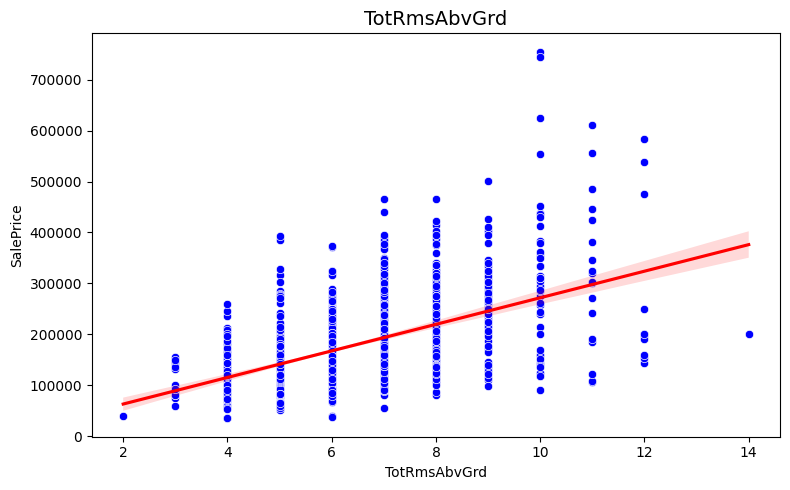

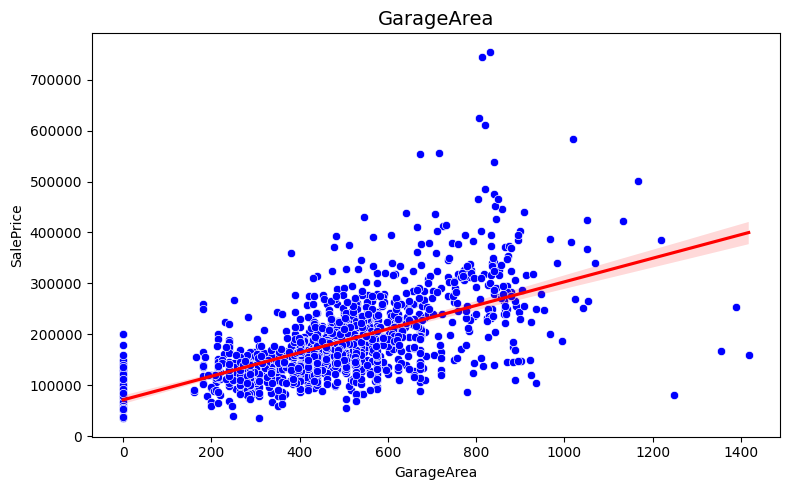

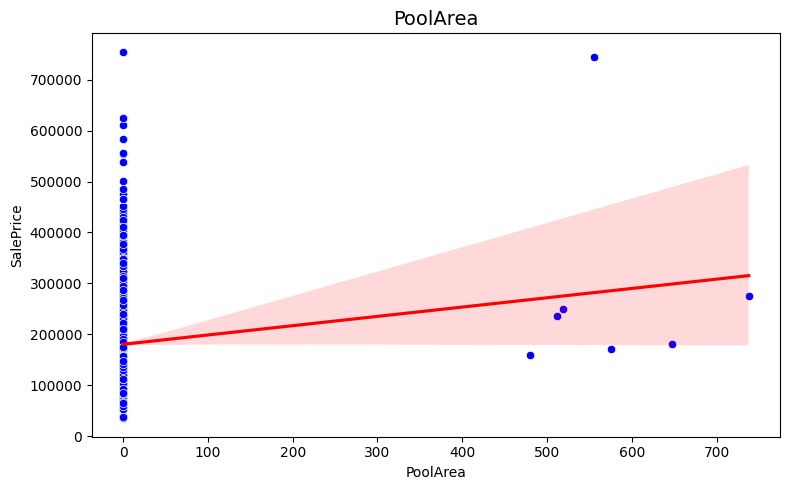

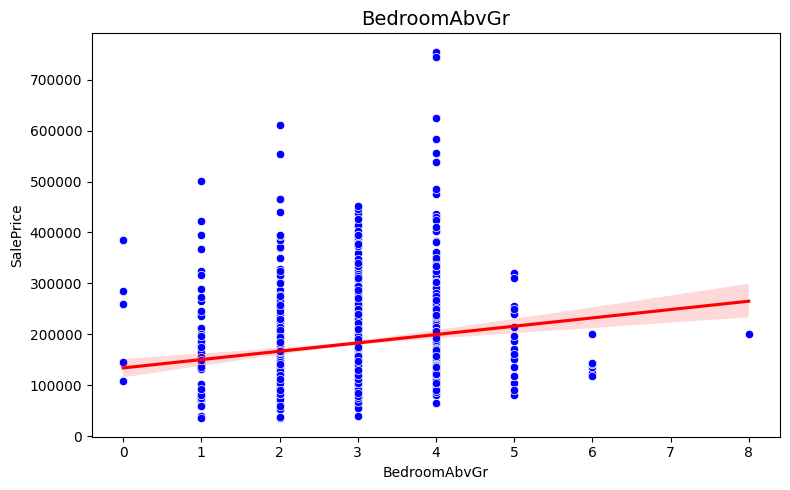

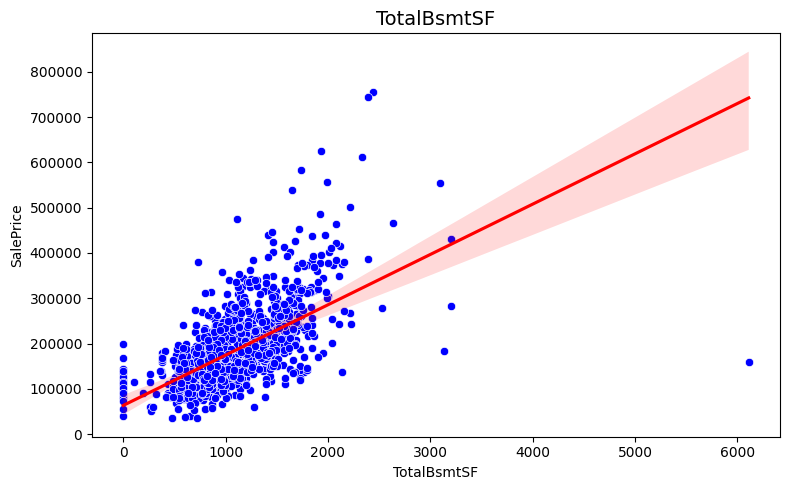

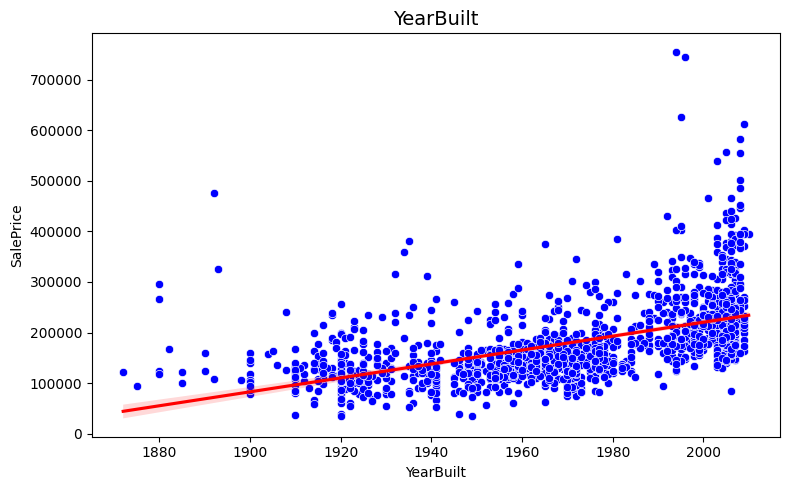

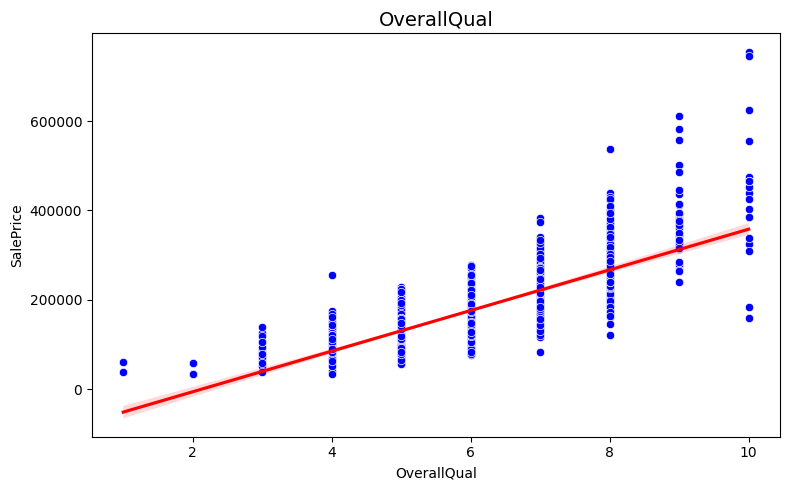

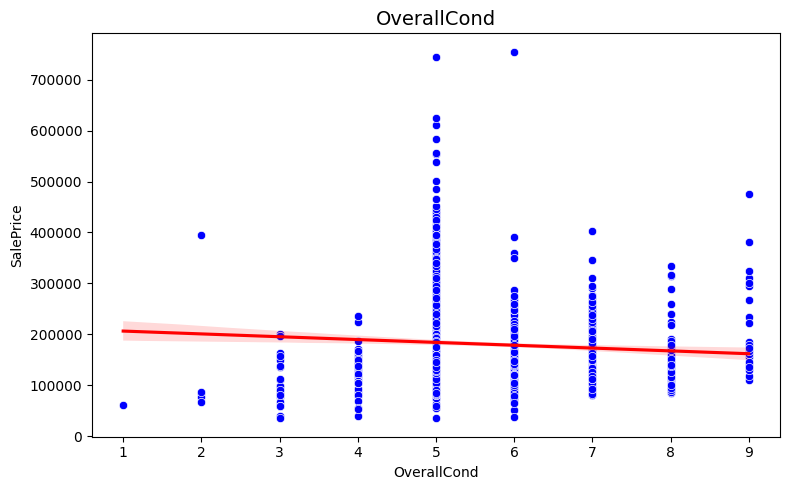

In [44]:
attributes = ["TotRmsAbvGrd", "GarageArea", "PoolArea", "BedroomAbvGr", "TotalBsmtSF", "YearBuilt", "OverallQual", "OverallCond"]
for attr in attributes:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=fullData, x=attr, y='SalePrice', color='blue')
    sns.regplot(data=fullData, x=attr, y='SalePrice', scatter=False, color='red')
    plt.title(f'{attr}', fontsize=14)
    plt.xlabel(attr)
    plt.ylabel('SalePrice')
    plt.tight_layout()
    plt.show()

Z tych ośmiu wykresów możemy również zauważyć korrelację pomiędzy danymi atrybutami a ceną mieszkania, ale możemy również zobaczyć atrybuty na które kupujący zadziwiająco nie skupiają uwagi, jak naprzykład najbardziej zaskakujący (a może nie przez jego subiektywność) Overall Condition, którego wykres pokazuje, że cena nawet ZMNIEJSZA się wraz z lepszym stanem domu co najlepiej pokazuję że na ten atrybut kupujący nie zwracają uwagi. Istnienie basenu wpływa na cenę, ale najdroższe budynki zwykle nie mają basenu, co pokazuje, że brak jego nie wpływa na cenę. Rok wybudowania ma duże znaczenie nad ceną, ale mniejsze niż ja osobiście się spodziewałem. Reszta atrybutów, czyli powierzchnia garażu, ilość pokoji nad ziemią (nie w piwnicy), ilość sypialni nad ziemią, wielkość piwnicy oraz ogólna jakość całkiem liniowo wpływają na cenę, są więc dobrym atrybutem na wykazanie ceny domu.